<a href="https://colab.research.google.com/github/AndrewLoweUoM/NFM/blob/main/Data_Preparation_Checking_TS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Drive

In [1]:
# Mount Drive
#from google.colab import drive
#drive.mount('/content/drive')

## Code Description:

This code performs a hydrological time-series workflow: loading 15-minute rainfall–flow data, exploring it, resampling to hourly and daily scales, visualising trends, and exporting processed datasets.

The script processes 15-minute rainfall and river flow time series data, then:

* Explores and visualises it
* Resamples it to hourly and daily scales
* Produces plots
* Exports processed datasets to CSV

## Data Loading & Initial Exploration

* Reads a CSV file containing:
  * Date
  * Flow_m3s (river discharge)
  * Rain_mm (rainfall)
* Uses pandas for handling data.

Then:
* Displays first rows (df.head())
* Checks:
   * Data shape  
   * Column names
   * Missing values
  * Summary statistics (describe())

### Load Data (15 mins) and Create DataFrame ``` df ```



In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the all data
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Oak_s50_2023_2024.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS.csv'
# Load the data
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_before.csv'
# Load the data
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_after.csv'

df = pd.read_csv(file_path)
# Displays start data in the Dataframe
df.head()

,Date,Flow_m3s,Rain_mm
0,05/12/2023 00:45:00,37.522647,0.2
1,05/12/2023 01:00:00,40.757528,0.4
2,05/12/2023 01:15:00,44.408012,0.4
3,05/12/2023 01:30:00,50.248908,0.4
4,05/12/2023 01:45:00,52.659141,0.2


### Display DataFrame Dimensions, Check Missing Values, and Describe Statistics

In [ ]:
# Displays DataFrame dimensions (rows and columns)
print('Shape of data:', df.shape)

Shape of data: (16417, 3)


In [ ]:
# Displays all columnns in the DataFrame
print(df.columns)

Index(['Date', 'Flow_m3s', 'Rain_mm'], dtype='object')


In [ ]:
# Check for missing values in the DataFrame
print(df.isnull().sum())

Date          0
Flow_m3s    572
Rain_mm       0
dtype: int64


In [ ]:
#replace null values with 0
#df.fillna(0, inplace=True)
#df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_3960/2385059866.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
# Display summary statistics of the DataFrame
print(df.describe())

           Flow_m3s       Rain_mm
count  15845.000000  16417.000000
mean      24.098050      0.084085
std       27.230930      0.273400
min        5.675991      0.000000
25%        9.606235      0.000000
50%       12.941819      0.000000
75%       24.965710      0.000000
max      167.309727      8.600000


## Time Handling

* Converts Date column to datetime (dayfirst=True)
* Sets Date as DataFrame index

This enables time-based operations like resampling

### Set Date as the Index for the DataFrame

In [ ]:
# Convert Date column to datetime objects using dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as the index for the DataFrame
df.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print('Index Type:', df.index.dtype)
print(df.head())

Index Type: datetime64[ns]
                      Flow_m3s  Rain_mm
Date                                   
2023-12-05 00:45:00  37.522647      0.2
2023-12-05 01:00:00  40.757528      0.4
2023-12-05 01:15:00  44.408012      0.4
2023-12-05 01:30:00  50.248908      0.4
2023-12-05 01:45:00  52.659141      0.2


## Data Visualisation (15 minute)

### Plot Rainfall and Flow Timeseries (15 minutes)

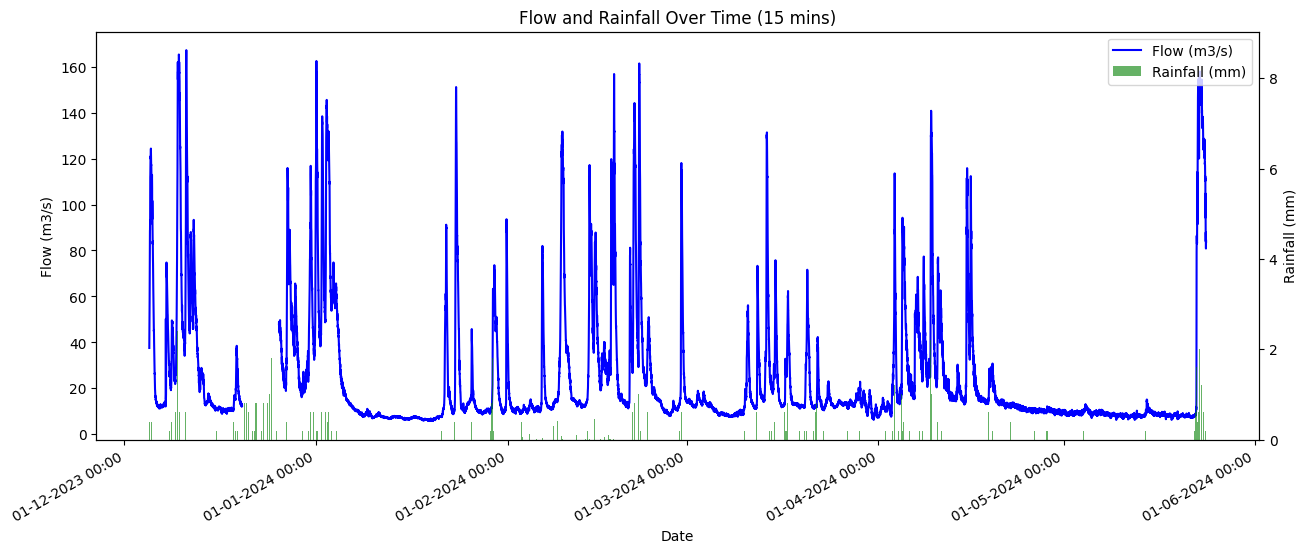

In [ ]:
# Create a figure and a set of subplots for 15 minute data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow' on the first y-axis
ax1.plot(df.index, df['Flow_m3s'], color='blue', label='Flow (m3/s)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis
ax2 = ax1.twinx()
# Plot 'Rain' on the second y-axis as bars
ax2.bar(df.index, df['Rain_mm'], color='green', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(minutes=10))
ax2.set_ylabel('Rainfall (mm)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Set title and add legends
plt.title('Flow and Rainfall Over Time (15 mins)')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

# Set x-axis date format to show full date and time
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)

# Improve date formatting on x-axis
fig.autofmt_xdate()

plt.show()

# Resampling to Hourly Data

### Data Loading & Time Handling

In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the all data to ensure 'df' is defined
#file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Oak_s50_2023_2024.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS.csv'
# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_before.csv'
# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_after.csv'

df = pd.read_csv(file_path)

# Convert Date column to datetime objects using dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as the index for the DataFrame
df.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print('Index Type:', df.index.dtype)
print(df.head())

Index Type: datetime64[ns]
                      Flow_m3s  Rain_mm
Date                                   
2023-12-05 00:45:00  37.522647      0.2
2023-12-05 01:00:00  40.757528      0.4
2023-12-05 01:15:00  44.408012      0.4
2023-12-05 01:30:00  50.248908      0.4
2023-12-05 01:45:00  52.659141      0.2


### Resamples 15 min Data to Hourly frequency to DataFrame ``` df_hourly ```



In [ ]:
# Resample the 15-minute data to hourly frequency
# Flow_m3s is averaged (mean) and Rain_mm is totaled (sum) for each hour
df_hourly = df.resample('h').agg({
    'Flow_m3s': 'mean',
    'Rain_mm': 'sum'
})

# Print the shape of the new hourly dataset
print('Shape of hourly data:', df_hourly.shape)

# Display the first few rows of the resampled data
df_hourly.head()

Shape of hourly data: (4105, 2)


,Flow_m3s,Rain_mm
Date,,
2023-12-05 00:00:00,37.522647,0.2
2023-12-05 01:00:00,47.018397,1.4
2023-12-05 02:00:00,70.072773,1.0
2023-12-05 03:00:00,88.958401,1.4
2023-12-05 04:00:00,106.630734,1.4


### Check Missing Values

In [ ]:
# Check missing Values
print(df_hourly.isnull().sum())

Flow_m3s    142
Rain_mm       0
dtype: int64


In [ ]:
print (df_hourly)

                       Flow_m3s  Rain_mm
Date                                    
2023-12-05 00:00:00   37.522647      0.2
2023-12-05 01:00:00   47.018397      1.4
2023-12-05 02:00:00   70.072773      1.0
2023-12-05 03:00:00   88.958401      1.4
2023-12-05 04:00:00  106.630734      1.4
...                         ...      ...
2024-05-23 20:00:00  117.636179      1.6
2024-05-23 21:00:00  111.696347      0.6
2024-05-23 22:00:00  100.697173      0.8
2024-05-23 23:00:00   87.547315      0.6
2024-05-24 00:00:00   83.583842      0.8

[4105 rows x 2 columns]


## Data Visualisation (Hourly)

### Plot Rainfall and Flow Timeseries (Hourly)

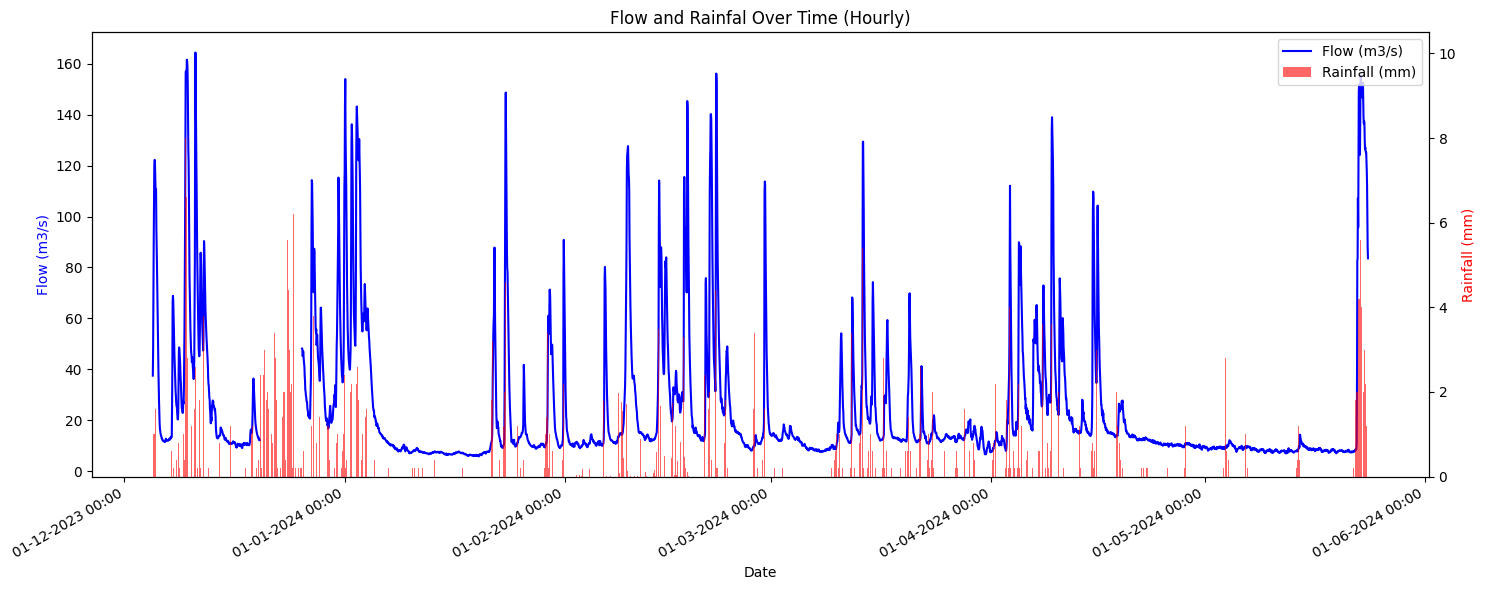

In [ ]:
# Create a figure and a set of subplots for hourly data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow_m3s' on the primary y-axis (ax1)
line1, = ax1.plot(df_hourly.index, df_hourly['Flow_m3s'], color='blue', label='Flow (m3/s)')

# Create a secondary y-axis (ax2)
ax2 = ax1.twinx()

# Plot 'Rain_mm' on the secondary y-axis (ax2) as bars
# Using pd.Timedelta(hours=0.8) for better alignment in hourly frequency
bars1 = ax2.bar(df_hourly.index, df_hourly['Rain_mm'], color='red', alpha=0.6, label='Rainfall (mm)', width=pd.Timedelta(hours=0.8))

# Set labels
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax2.set_ylabel('Rainfall (mm)', color='red')

# Format x-axis
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

# Add title and combined legend
plt.title('Flow and Rainfal Over Time (Hourly)')
lines = [line1, bars1]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

### Output Timeseries (hourly) CSV file

In [ ]:
# Define the all hourly timeseries output file path
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_hourly.csv'
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly.csv'
# Define the before NFM hourly timeseries output file path
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly_before.csv'
# Define the after NFM hourly timeseries output file path
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_hourly_after.csv'

# Save the df_hourly to CSV
df_hourly.to_csv(final_output_path)

print(f'Successfully saved event adjusted results to: {final_output_path}')

Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_hourly.csv


# Rasampling to Daily Data

## Data Loading & Time Handling

In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Oak_s50_2023_2024.csv'
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS.csv'
# Load the before NFM data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_before.csv'
# Load the all data to ensure 'df' is defined
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Bollington-Mill-rain-flow-15min-TS_after.csv'

df = pd.read_csv(file_path)

# Convert Date column to datetime objects using dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set Date as the index for the DataFrame
df.set_index('Date', inplace=True)

# Verify the change by checking the index type and first 5 rows
print('Index Type:', df.index.dtype)
print(df.head())

Index Type: datetime64[ns]
                      Flow_m3s  Rain_mm
Date                                   
2023-12-05 00:45:00  37.522647      0.2
2023-12-05 01:00:00  40.757528      0.4
2023-12-05 01:15:00  44.408012      0.4
2023-12-05 01:30:00  50.248908      0.4
2023-12-05 01:45:00  52.659141      0.2


### Resample to Daily frequency to DataFrame ``` df_daily ```



In [ ]:
# Resample the 15-minute data to daily frequency
# Flow_m3s is averaged (mean) and Rain_mm is totaled (sum) for each hour
df_daily = df.resample('D').agg({
    'Flow_m3s': 'mean',
    'Rain_mm': 'sum'
})

# Print the shape of the new daily dataset
print('Shape of daily data:', df_daily.shape)

# Display the first few rows of the resampled data
df_daily.head()

Shape of daily data: (172, 2)


,Flow_m3s,Rain_mm
Date,,
2023-12-05,76.329607,12.0
2023-12-06,12.774779,0.0
2023-12-07,25.017225,8.2
2023-12-08,34.660542,6.6
2023-12-09,85.690316,52.4


### Check Missing Values

In [ ]:
# Check missing Values
print(df_daily.isnull().sum())

Flow_m3s    5
Rain_mm     0
dtype: int64


In [ ]:
print (df_daily)

              Flow_m3s  Rain_mm
Date                           
2023-12-05   76.329607     12.0
2023-12-06   12.774779      0.0
2023-12-07   25.017225      8.2
2023-12-08   34.660542      6.6
2023-12-09   85.690316     52.4
...                ...      ...
2024-05-20    7.885121      0.0
2024-05-21    7.766138      0.4
2024-05-22   68.166824     67.2
2024-05-23  133.424546     62.2
2024-05-24   83.583842      0.8

[172 rows x 2 columns]


## Data Visualisation (Daily)

### Plot Rainfall and Flow Timeseries (Daily)

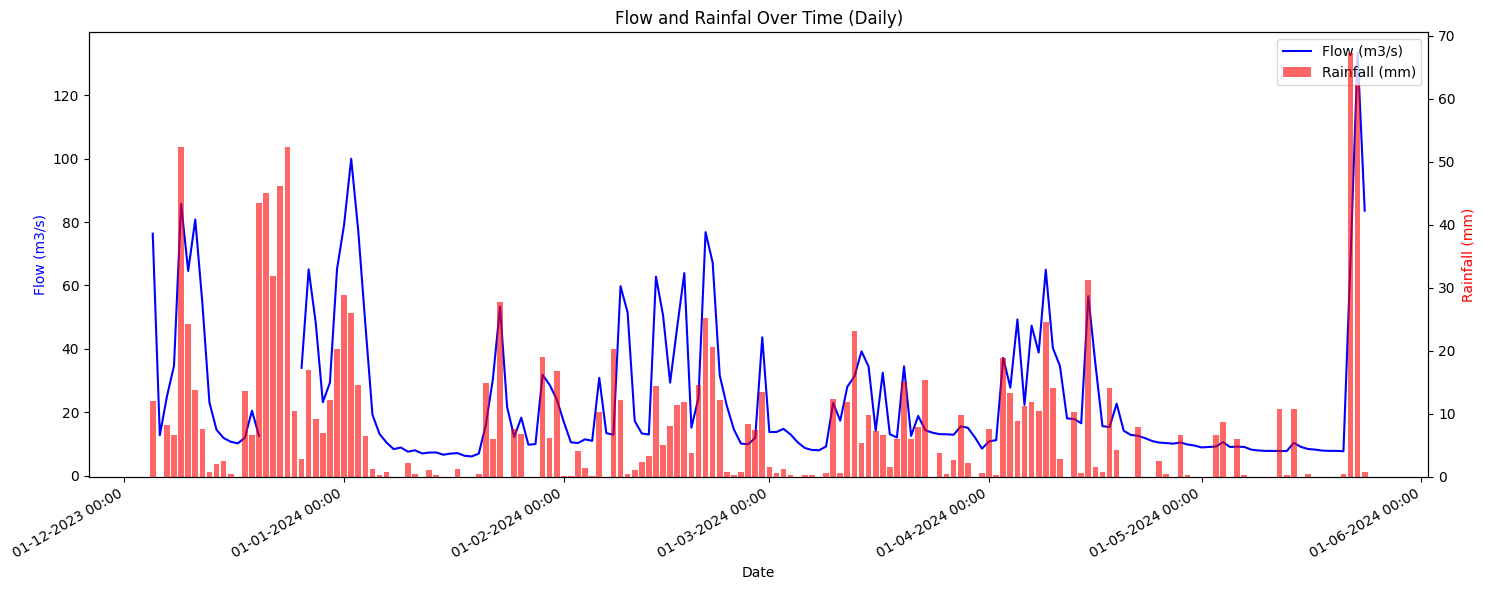

In [ ]:
# Create a figure and a set of subplots for daily data
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Flow_m3s' on the primary y-axis (ax1)
line1, = ax1.plot(df_daily.index, df_daily['Flow_m3s'], color='blue', label='Flow (m3/s)')

# Create a secondary y-axis (ax2)
ax2 = ax1.twinx()

# Plot 'Rain_mm' on the secondary y-axis (ax2) as bars
bars1 = ax2.bar(df_daily.index, df_daily['Rain_mm'], color='red', alpha=0.6, label='Rainfall (mm)', width=0.8)

# Set labels
ax1.set_xlabel('Date')
ax1.set_ylabel('Flow (m3/s)', color='blue')
ax2.set_ylabel('Rainfall (mm)', color='red')

# Format x-axis
date_form = DateFormatter('%d-%m-%Y %H:%M')
ax1.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

# Add title and combined legend
plt.title('Flow and Rainfal Over Time (Daily)')
lines = [line1, bars1]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

# Show plot
plt.tight_layout()
plt.show()

### Output Timeseries (daily) CSV file



In [ ]:
# Define all daily timeseries output file path
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_daily.csv'
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily.csv'
# Define the daily timeseries output file path
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily_before.csv'
# Define the daily timeseries output file path
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Bollington-Mill-rain-flow-15min-TS_daily_after.csv'

# Save the df_daily to CSV
df_daily.to_csv(final_output_path)

print(f'Successfully saved event adjusted results to: {final_output_path}')

Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Input/Timeseries/Resampled/Oak_s50_2023_2024_daily.csv
